# 🌍 AI-Driven Country Intelligence and Development Segmentation System
## Using Ensemble Learning & Clustering

---

| | |
|---|---|
| **Dataset** | HELP International Country Data (Kaggle) |
| **Techniques** | K-Means, DBSCAN, PCA, Random Forest, XGBoost, SHAP |
| **Goal** | Cluster countries by development level → classify with ML |
| **Type** | Unsupervised → Supervised Learning Pipeline |

---

> **Project Summary:** HELP International, an NGO, needs to categorise countries by socioeconomic and health factors to allocate aid strategically. This notebook builds a complete ML pipeline — from raw data to actionable country intelligence — using clustering, dimensionality reduction, and ensemble classification.


In [1]:
!pip install shap

## 📦 Section 1 — Import Libraries

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 : IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────────────────────

# Standard libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Scikit-learn — preprocessing & utilities
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Scikit-learn — clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Ensemble models
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier, plot_importance as xgb_plot_importance

# SHAP for model explainability
import shap

# ── Global settings ──────────────────────────────────────────────────────────
SEED        = 42
np.random.seed(SEED)

# Seaborn / Matplotlib style
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'      : 120,
    'figure.figsize'  : (12, 5),
    'axes.titlesize'  : 14,
    'axes.labelsize'  : 12,
    'axes.titleweight': 'bold',
})

# Custom colour palette used throughout
PALETTE   = ['#2ECC71', '#E67E22', '#E74C3C']   # green / orange / red
CMAP_HEAT = 'coolwarm'

print("✅ All libraries imported successfully.")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")
print(f"   Seaborn: {sns.__version__}")


✅ All libraries imported successfully.
   NumPy  : 2.4.6
   Pandas : 3.0.3
   Seaborn: 0.13.2


## 📂 Section 2 — Load Dataset

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 : LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv('country-data.csv')

print("=" * 55)
print("  DATASET LOADED SUCCESSFULLY")
print("=" * 55)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print("=" * 55)

# First look
print("\n── First 5 rows ──")
df.head()


  DATASET LOADED SUCCESSFULLY
  Rows    : 167
  Columns : 10

── First 5 rows ──


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
# Column data-types and non-null counts
print("── Dataset Info ──")
df.info()


── Dataset Info ──
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


In [5]:
# Statistical summary of all numeric features
print("── Descriptive Statistics ──")
df.describe().round(2)


── Descriptive Statistics ──


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


## 🧠 Section 3 — Data Understanding

### Problem Statement
HELP International has raised ~\$10 million to be spent strategically on countries in dire need.  
The CEO needs a data-driven answer to: **"Which countries are most in need of aid?"**

### Dataset Overview
| Column | Description |
|---|---|
| `country` | Country name (identifier) |
| `child_mort` | Deaths per 1,000 live births under age 5 |
| `exports` | Exports as % of GDP |
| `health` | Health spending as % of GDP |
| `imports` | Imports as % of GDP |
| `income` | Net income per person (USD) |
| `inflation` | Annual inflation rate (%) |
| `life_expec` | Life expectancy (years) |
| `total_fer` | Average number of children per woman |
| `gdpp` | GDP per capita (USD) |

### ML Objective
Since there is **no pre-existing target variable**, we will:
1. Apply **K-Means clustering** to group countries by socioeconomic similarity  
2. Interpret clusters as *Developed / Developing / Underdeveloped*  
3. Use these labels as the **target variable** for supervised classification  
4. Train **Random Forest** and **XGBoost** classifiers on these labels  


## 🧹 Section 4 — Data Cleaning & Quality Checks

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 : DATA CLEANING
# ─────────────────────────────────────────────────────────────────────────────

# ── 4.1  Missing values ──────────────────────────────────────────────────────
null_summary = df.isnull().sum().reset_index()
null_summary.columns = ['Feature', 'Missing Count']
null_summary['Missing %'] = (null_summary['Missing Count'] / len(df) * 100).round(2)
print("── Missing Values ──")
print(null_summary.to_string(index=False))

# ── 4.2  Duplicates ──────────────────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"\n── Duplicate Rows : {dup_count} ──")

# ── 4.3  Data-types ──────────────────────────────────────────────────────────
print("\n── Data Types ──")
print(df.dtypes)


── Missing Values ──
   Feature  Missing Count  Missing %
   country              0        0.0
child_mort              0        0.0
   exports              0        0.0
    health              0        0.0
   imports              0        0.0
    income              0        0.0
 inflation              0        0.0
life_expec              0        0.0
 total_fer              0        0.0
      gdpp              0        0.0

── Duplicate Rows : 0 ──

── Data Types ──
country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


In [7]:
# ── 4.4  Outlier Detection & Handling (IQR method) ───────────────────────────

# Numeric features only (exclude country name)
num_cols = df.select_dtypes(include=np.number).columns.tolist()

def cap_outliers_iqr(dataframe, columns):
    """Cap outliers at the IQR whisker boundaries (Winsorisation)."""
    df_clean = dataframe.copy()
    report   = []
    for col in columns:
        Q1  = df_clean[col].quantile(0.25)
        Q3  = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lo  = Q1 - 1.5 * IQR
        hi  = Q3 + 1.5 * IQR
        n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
        df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
        report.append({'Feature': col, 'Outliers Capped': n_out,
                       'Lower Bound': round(lo, 2), 'Upper Bound': round(hi, 2)})
    return df_clean, pd.DataFrame(report)

df_clean, outlier_report = cap_outliers_iqr(df, num_cols)

print("── Outlier Capping Report (IQR Method) ──")
print(outlier_report.to_string(index=False))
print(f"\n✅ Dataset shape after cleaning : {df_clean.shape}")


── Outlier Capping Report (IQR Method) ──
   Feature  Outliers Capped  Lower Bound  Upper Bound
child_mort                4       -72.53       142.88
   exports                5       -17.52        92.67
    health                2        -0.60        14.12
   imports                4       -12.63       101.58
    income                8    -25812.50     51967.50
 inflation                5       -11.60        24.16
life_expec                3        48.05        94.05
 total_fer                1        -1.33         7.01
      gdpp               25    -17750.00     33130.00

✅ Dataset shape after cleaning : (167, 10)


## 📊 Section 5 — Exploratory Data Analysis (EDA)

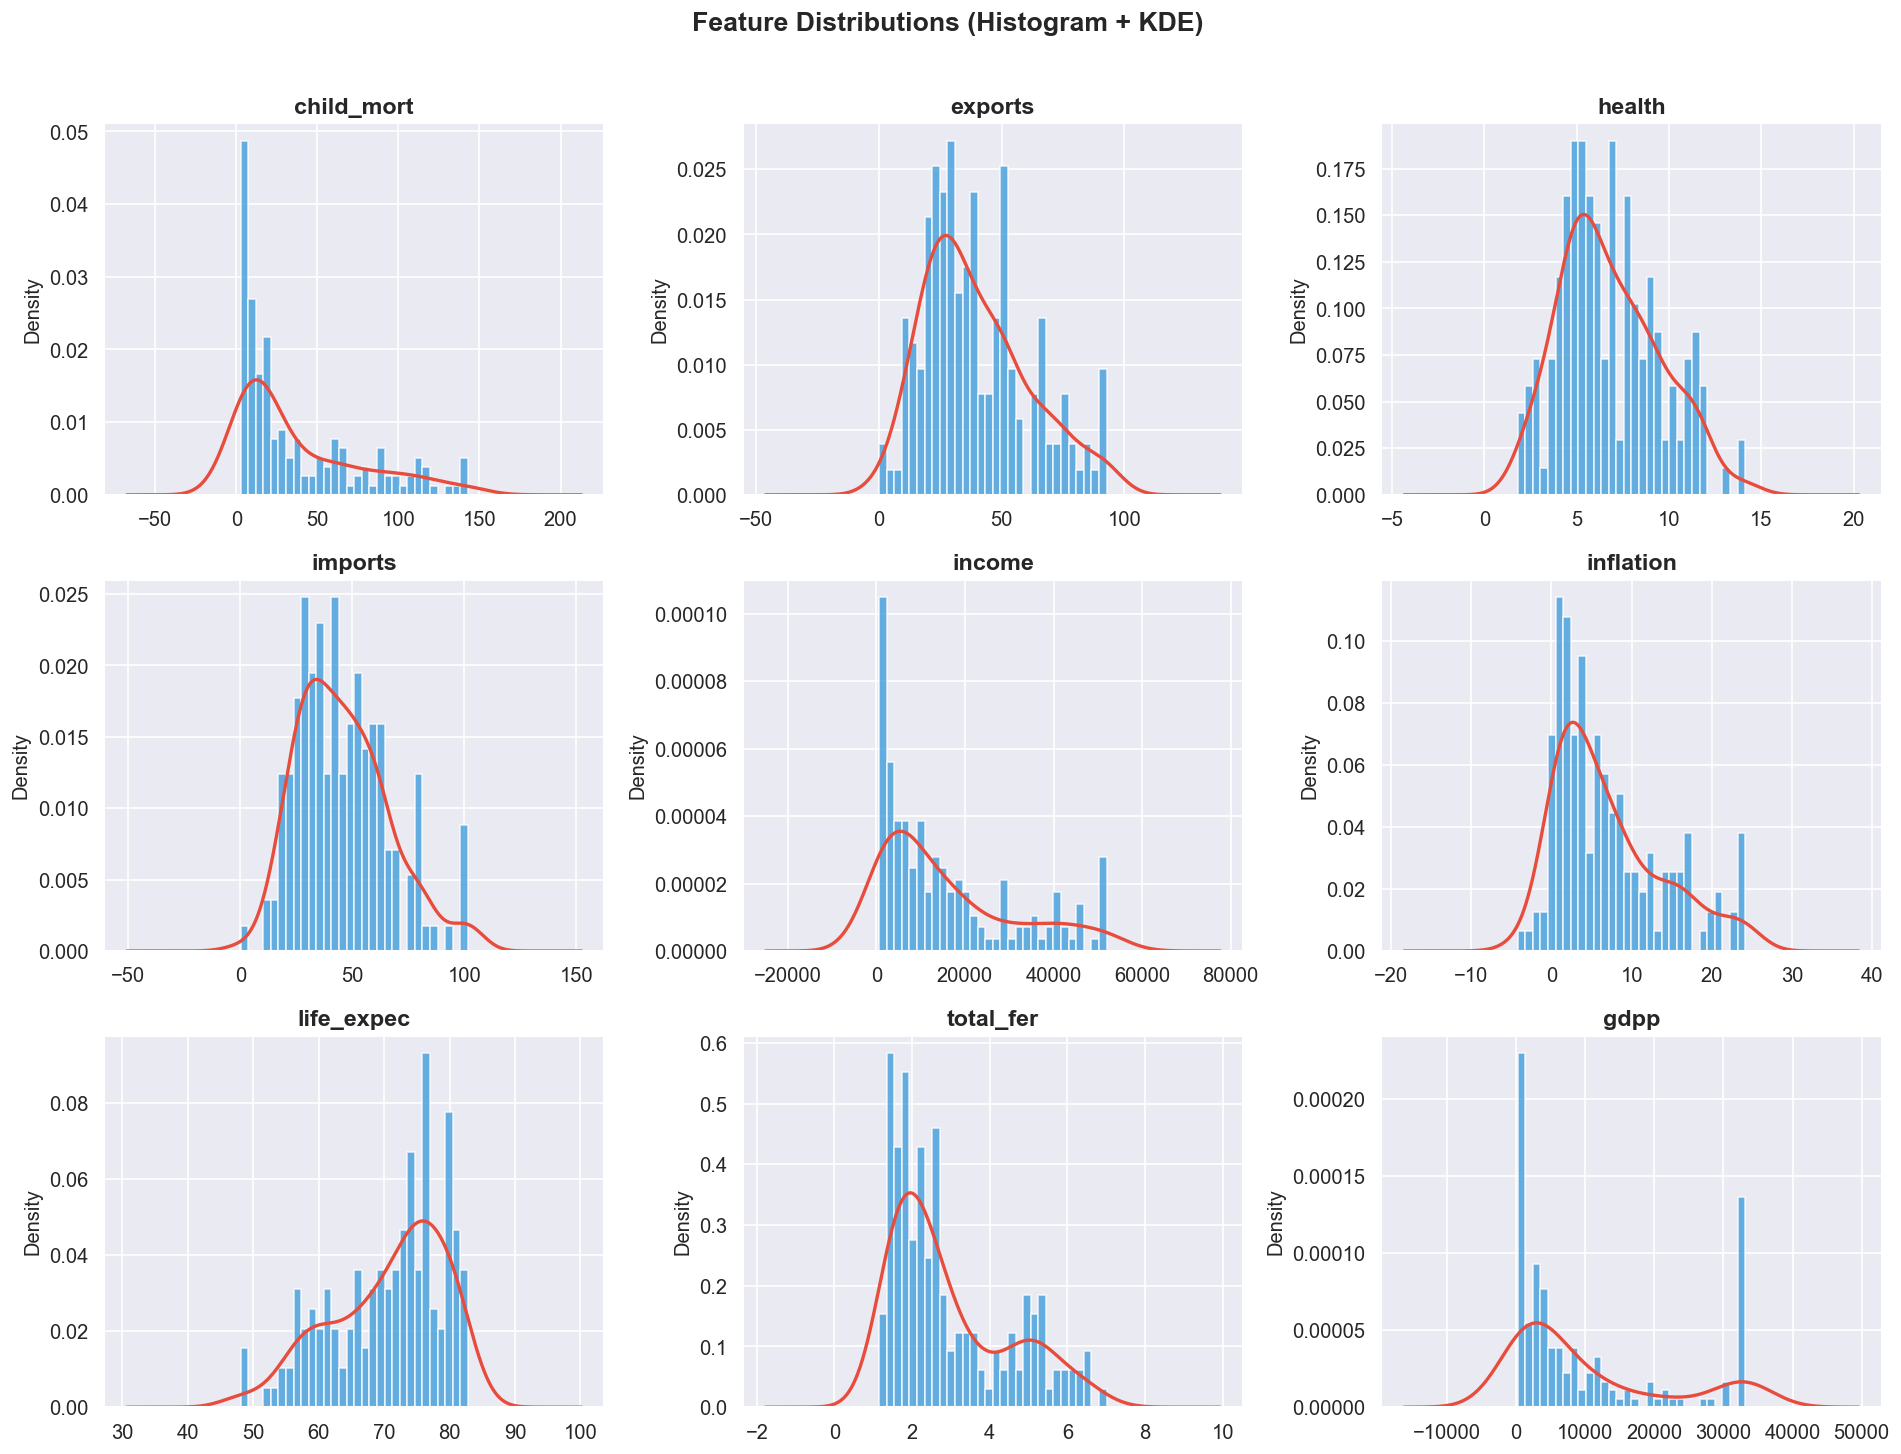

📌 Insight: income & gdpp are heavily right-skewed — most countries are low-income, with a few wealthy outliers pulling the mean up.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 : EDA
# ─────────────────────────────────────────────────────────────────────────────

# ── 5.1  Distribution of all numeric features (histograms + KDE) ─────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=30, color='#3498DB', edgecolor='white',
                 alpha=0.75, density=True)
    df_clean[col].plot(kind='kde', ax=axes[i], color='#E74C3C', linewidth=2)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions (Histogram + KDE)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
# # # plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()
print("📌 Insight: income & gdpp are heavily right-skewed — most countries are low-income,"
      " with a few wealthy outliers pulling the mean up.")


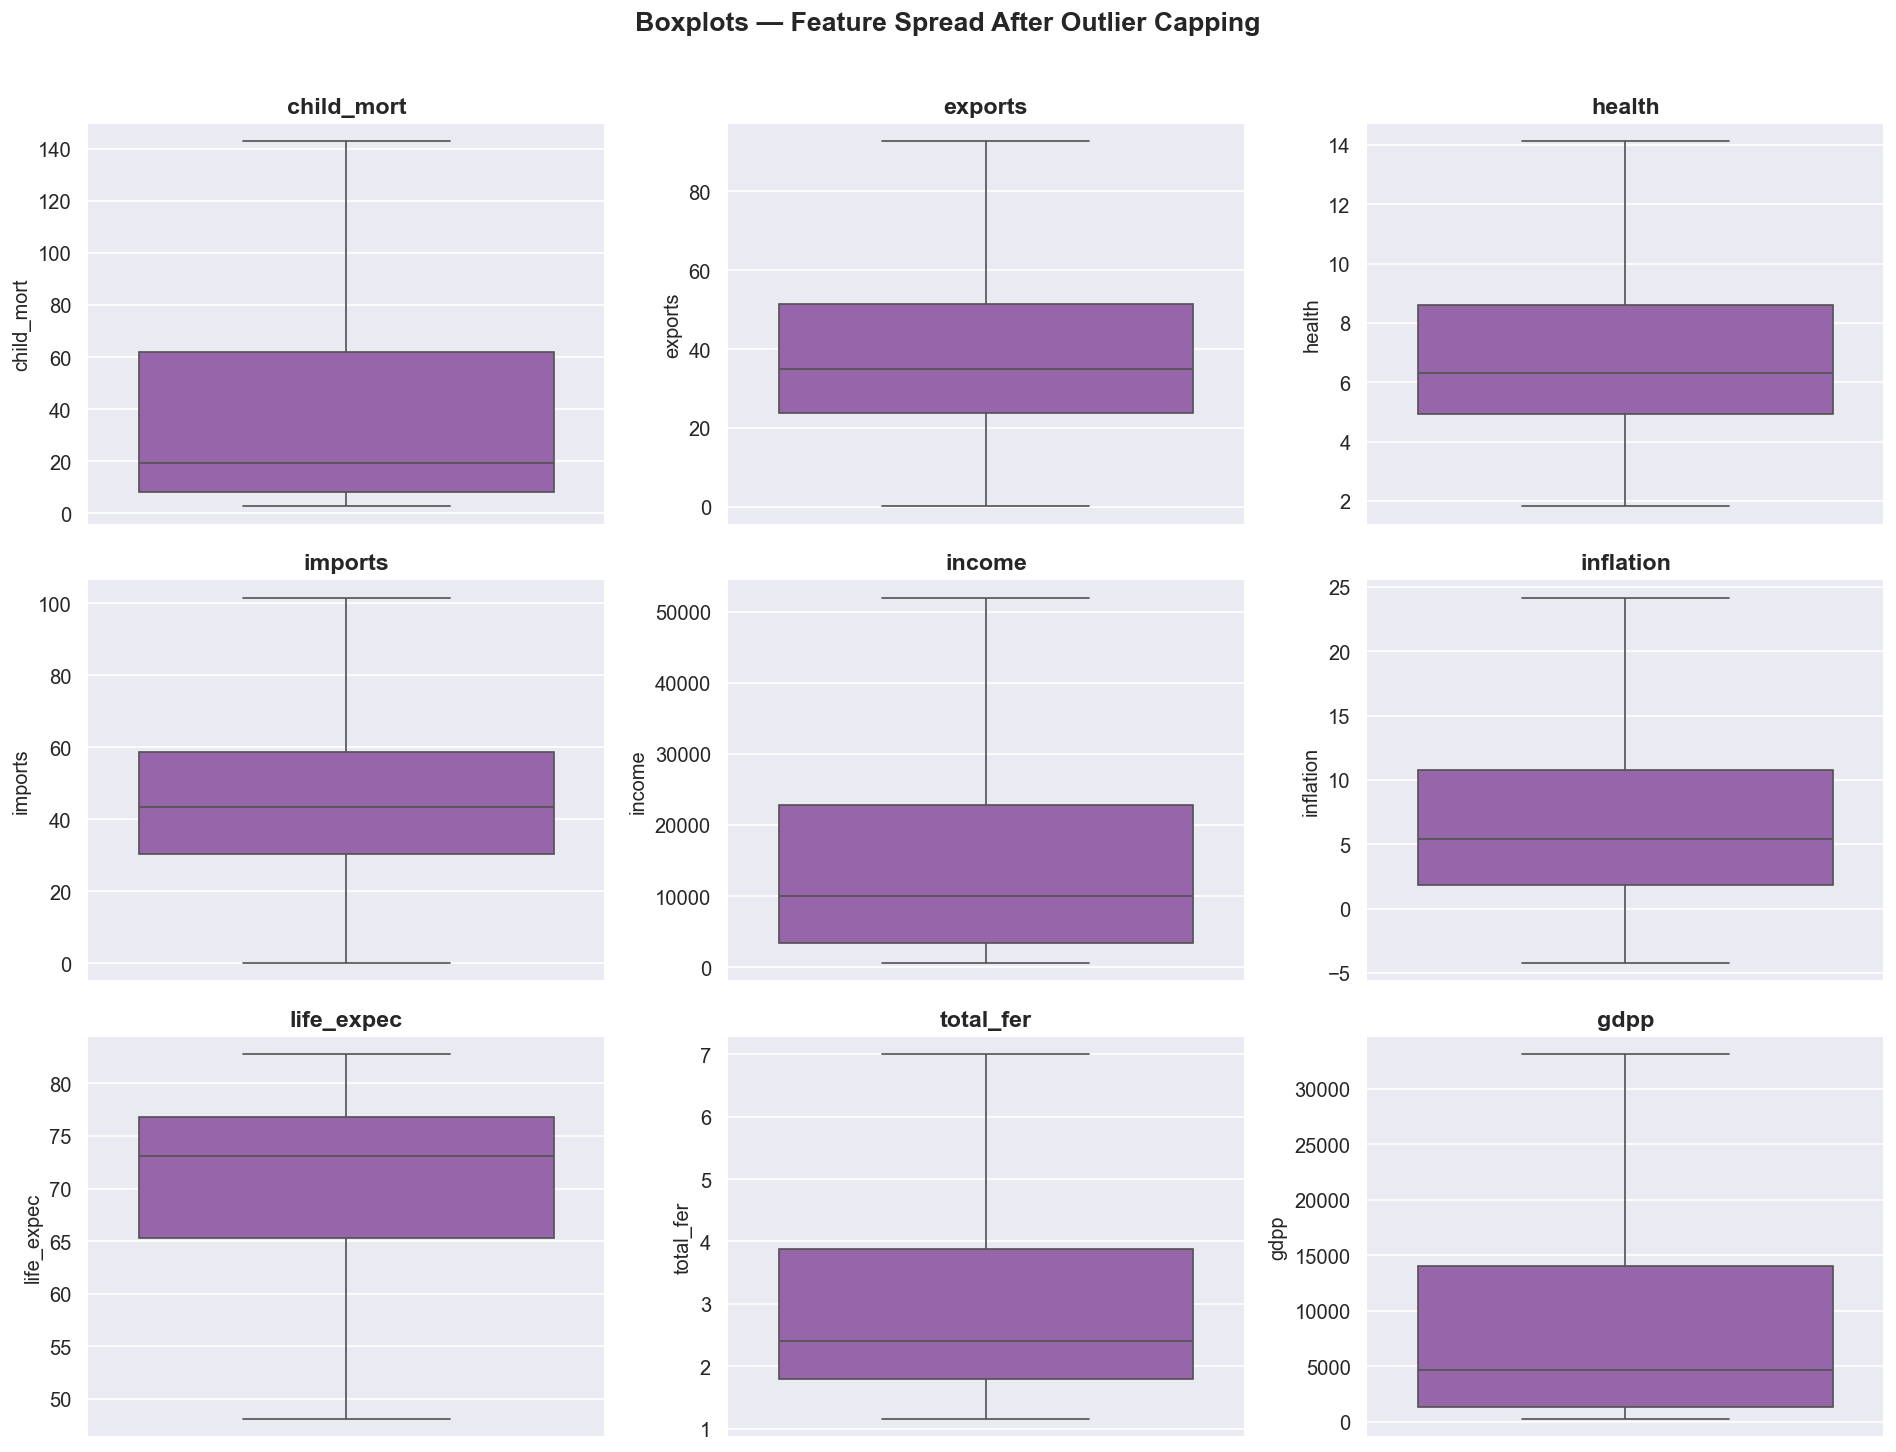

📌 Insight: child_mort and total_fer remain wide-ranged — key differentiators between developed and underdeveloped nations.


In [9]:
# ── 5.2  Boxplots — spread & remaining outlier check ─────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='#9B59B6',
                flierprops=dict(marker='o', color='red', markersize=4))
    axes[i].set_title(col)

plt.suptitle('Boxplots — Feature Spread After Outlier Capping', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
# # plt.savefig('eda_boxplots.png', bbox_inches='tight')
plt.show()
print("📌 Insight: child_mort and total_fer remain wide-ranged — key differentiators"
      " between developed and underdeveloped nations.")


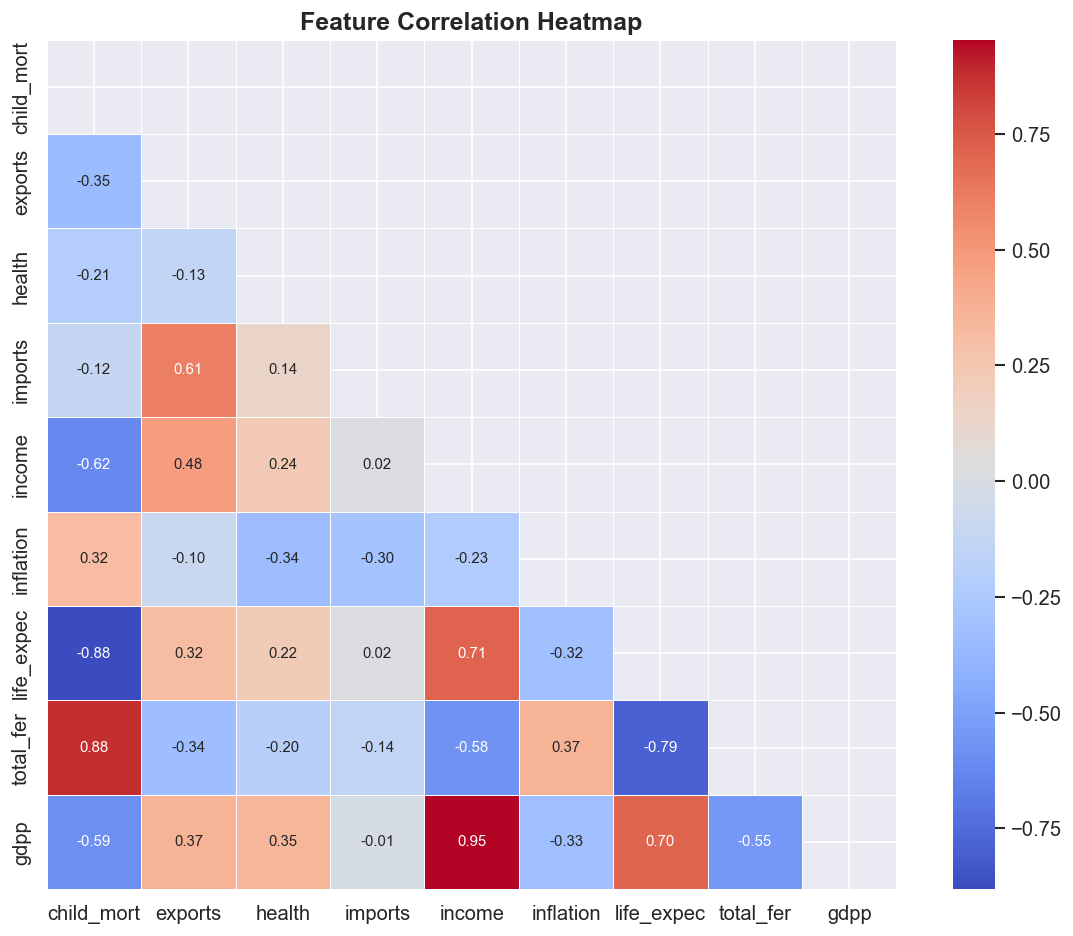

📌 Insight: income & gdpp are strongly correlated (r≈0.9).  child_mort negatively correlates with life_expec (r≈-0.87), confirming health-poverty link.


In [10]:
# ── 5.3  Correlation Heatmap ─────────────────────────────────────────────────
corr = df_clean[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=CMAP_HEAT,
            mask=mask, linewidths=0.5,
            annot_kws={'size': 9}, square=True)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
# # plt.savefig('eda_heatmap.png', bbox_inches='tight')
plt.show()
print("📌 Insight: income & gdpp are strongly correlated (r≈0.9)."
      "  child_mort negatively correlates with life_expec (r≈-0.87),"
      " confirming health-poverty link.")


In [11]:
# ── 5.4  Income vs GDP per Capita (Plotly interactive) ───────────────────────
fig = px.scatter(
    df_clean, x='gdpp', y='income',
    hover_name='country',
    color='life_expec',
    color_continuous_scale='Viridis',
    size='child_mort',
    size_max=25,
    title='Income vs GDP per Capita — sized by Child Mortality',
    labels={'gdpp': 'GDP per Capita (USD)', 'income': 'Income per Person (USD)',
            'life_expec': 'Life Expectancy'},
    template='plotly_dark'
)
fig.update_layout(title_font_size=16)
fig.show()
print("📌 Insight: High-GDP countries cluster top-right with low child mortality (small bubbles)."
      " Sub-Saharan African countries occupy the bottom-left.")


📌 Insight: High-GDP countries cluster top-right with low child mortality (small bubbles). Sub-Saharan African countries occupy the bottom-left.


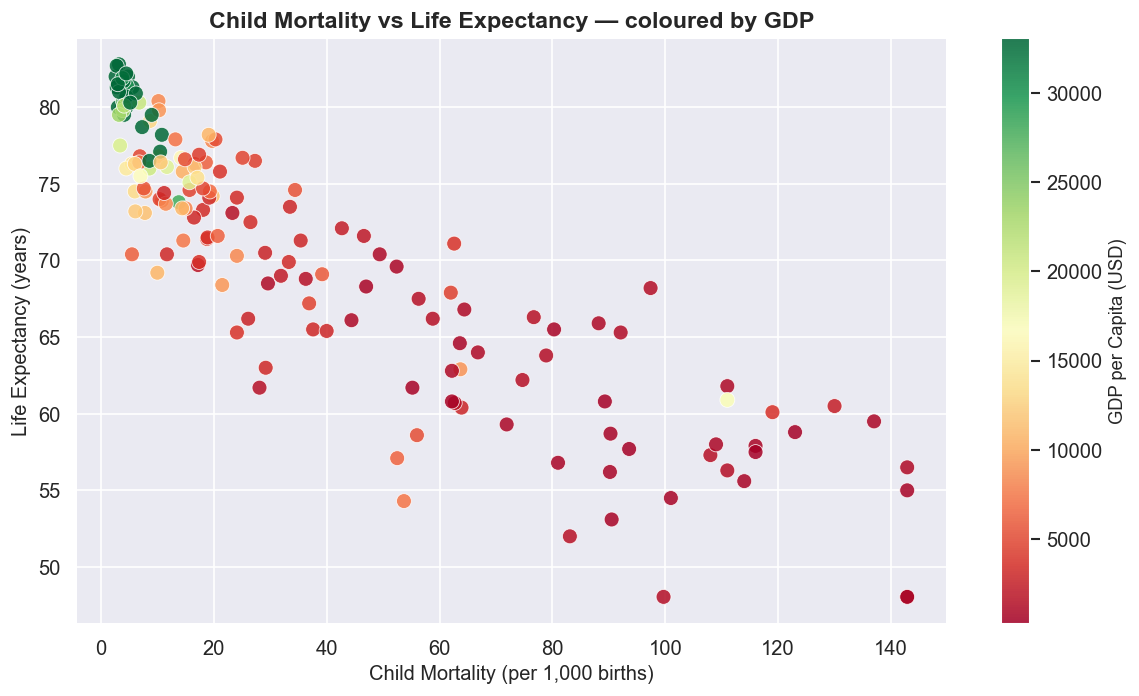

📌 Insight: Clear inverse relationship — as child mortality rises, life expectancy drops sharply, with the poorest countries (dark red) at the extreme.


In [12]:
# ── 5.5  Child Mortality vs Life Expectancy ──────────────────────────────────
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_clean['child_mort'], df_clean['life_expec'],
                      c=df_clean['gdpp'], cmap='RdYlGn',
                      s=80, edgecolors='white', linewidth=0.5, alpha=0.85)
cbar = plt.colorbar(scatter)
cbar.set_label('GDP per Capita (USD)', fontsize=11)
plt.xlabel('Child Mortality (per 1,000 births)')
plt.ylabel('Life Expectancy (years)')
plt.title('Child Mortality vs Life Expectancy — coloured by GDP', fontweight='bold')
plt.tight_layout()
# # plt.savefig('eda_child_life.png', bbox_inches='tight')
plt.show()
print("📌 Insight: Clear inverse relationship — as child mortality rises, life expectancy"
      " drops sharply, with the poorest countries (dark red) at the extreme.")


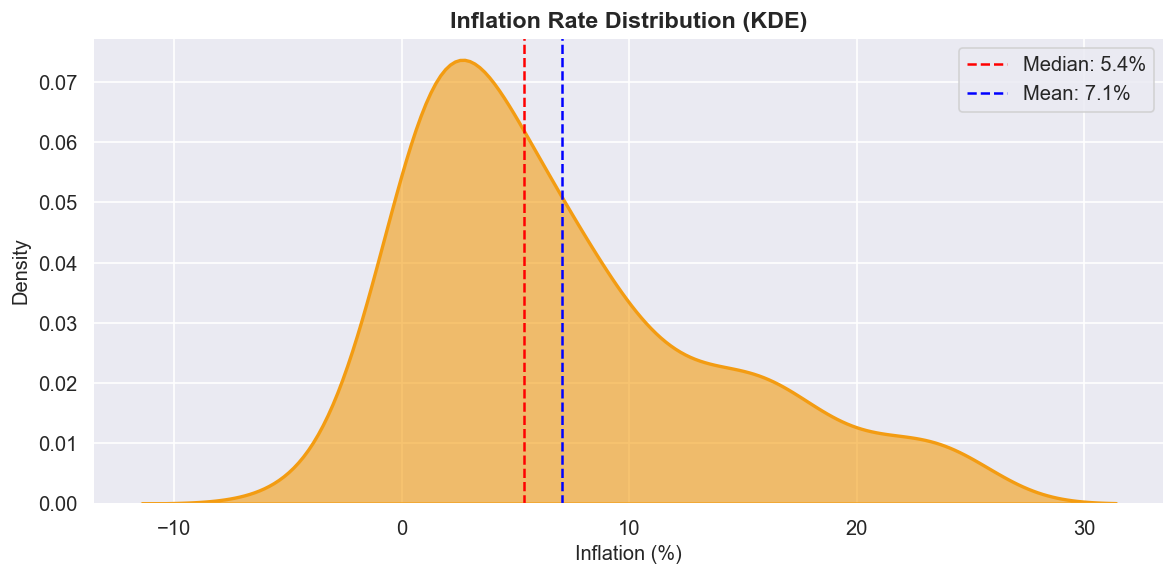

📌 Insight: Most countries have moderate inflation (5–10%). The right tail represents hyperinflationary economies — a strong risk indicator.


In [13]:
# ── 5.6  Inflation Distribution (KDE) ────────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.kdeplot(df_clean['inflation'], fill=True, color='#F39C12', linewidth=2, alpha=0.6)
plt.axvline(df_clean['inflation'].median(), color='red', linestyle='--',
            label=f"Median: {df_clean['inflation'].median():.1f}%")
plt.axvline(df_clean['inflation'].mean(), color='blue', linestyle='--',
            label=f"Mean: {df_clean['inflation'].mean():.1f}%")
plt.title('Inflation Rate Distribution (KDE)', fontweight='bold')
plt.xlabel('Inflation (%)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
# # plt.savefig('eda_inflation.png', bbox_inches='tight')
plt.show()
print("📌 Insight: Most countries have moderate inflation (5–10%). The right tail represents"
      " hyperinflationary economies — a strong risk indicator.")


In [14]:
# ── 5.7  Exports vs Imports comparison ───────────────────────────────────────
fig = px.scatter(
    df_clean, x='exports', y='imports',
    hover_name='country',
    color='income',
    color_continuous_scale='Blues',
    title='Exports vs Imports (% of GDP) — coloured by Income',
    labels={'exports': 'Exports (% GDP)', 'imports': 'Imports (% GDP)',
            'income': 'Income'},
    template='plotly_white', size_max=15
)
fig.add_shape(type='line', x0=0, y0=0, x1=df_clean['exports'].max(),
              y1=df_clean['exports'].max(),
              line=dict(dash='dash', color='red', width=1.5))
fig.add_annotation(text='Exports = Imports', x=60, y=62,
                   showarrow=False, font=dict(color='red'))
fig.show()
print("📌 Insight: Countries above the diagonal are net importers (trade deficit)."
      " High-income countries tend to cluster around balanced trade.")


📌 Insight: Countries above the diagonal are net importers (trade deficit). High-income countries tend to cluster around balanced trade.


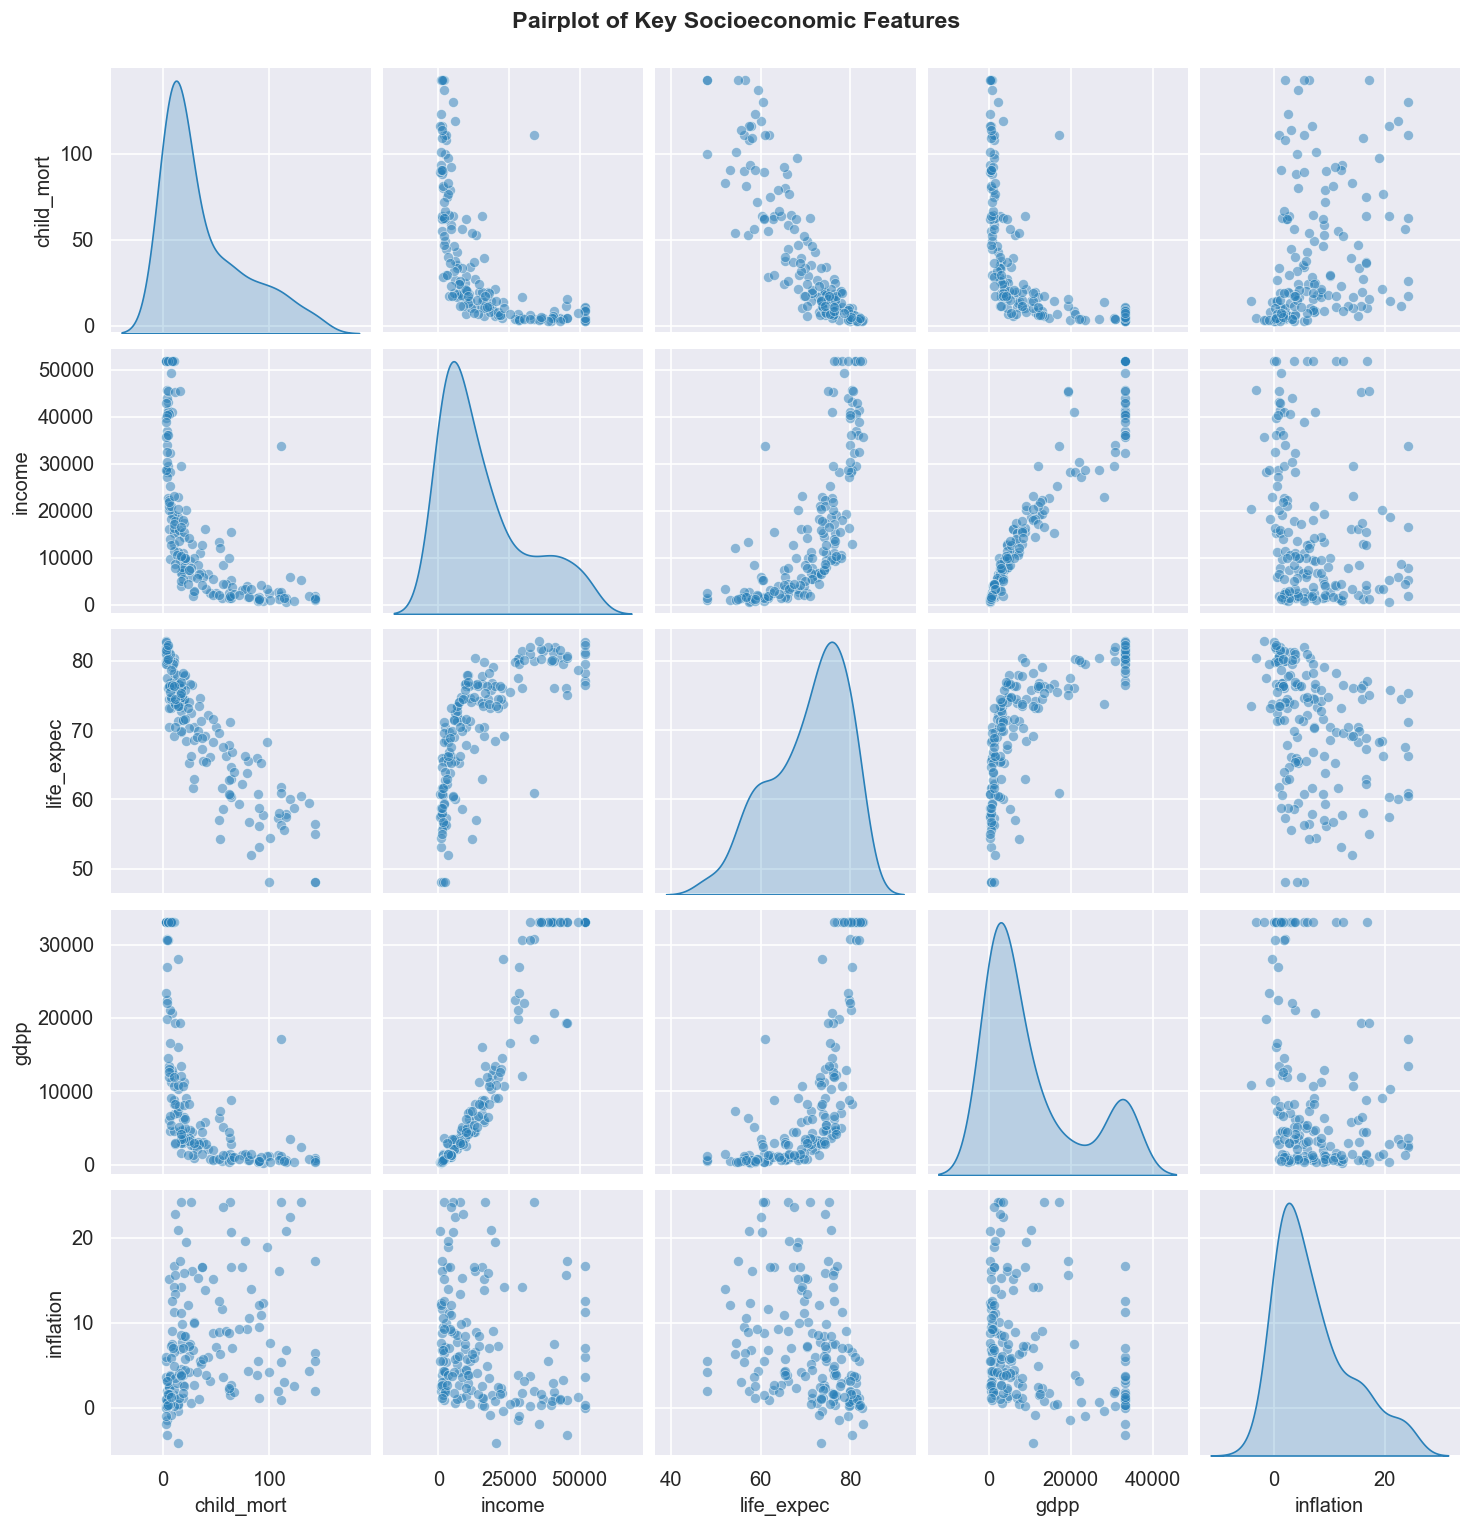

📌 Insight: income-gdpp shows near-linear correlation.  child_mort-life_expec shows a clear hyperbolic inverse relationship.


In [15]:
# ── 5.8  Pairplot of key features ────────────────────────────────────────────
key_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'inflation']
pair_df = df_clean[key_features].copy()

g = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.5, 'color': '#2980B9'},
                 diag_kws={'fill': True, 'color': '#2980B9'})
g.figure.suptitle('Pairplot of Key Socioeconomic Features', y=1.02, fontsize=14,
                   fontweight='bold')
# # plt.savefig('eda_pairplot.png', bbox_inches='tight')
plt.show()
print("📌 Insight: income-gdpp shows near-linear correlation."
      "  child_mort-life_expec shows a clear hyperbolic inverse relationship.")


## ⚙️ Section 6 — Feature Engineering

### Custom Feature: `risk_score`

We engineer a composite **risk score** to quantify each country's vulnerability:

$$\text{risk\_score} = (child\_mort \times 0.3) + (inflation \times 0.2) - (life\_expec \times 0.2) - (income \times 0.3)$$

**Why this works:**
- High child mortality → increases risk
- High inflation → economic instability
- High life expectancy → reduces risk (sign of development)
- High income → reduces risk (economic strength)

After computing we **min-max normalise** it to [0, 1] for interpretability.


── Top 10 Highest-Risk Countries ──
                 country  risk_score
        Congo, Dem. Rep.    1.000000
                 Liberia    0.997474
                 Burundi    0.996443
                   Niger    0.995902
Central African Republic    0.994984
              Mozambique    0.993578
                  Malawi    0.991275
            Sierra Leone    0.988644
                  Guinea    0.988516
                    Togo    0.987562


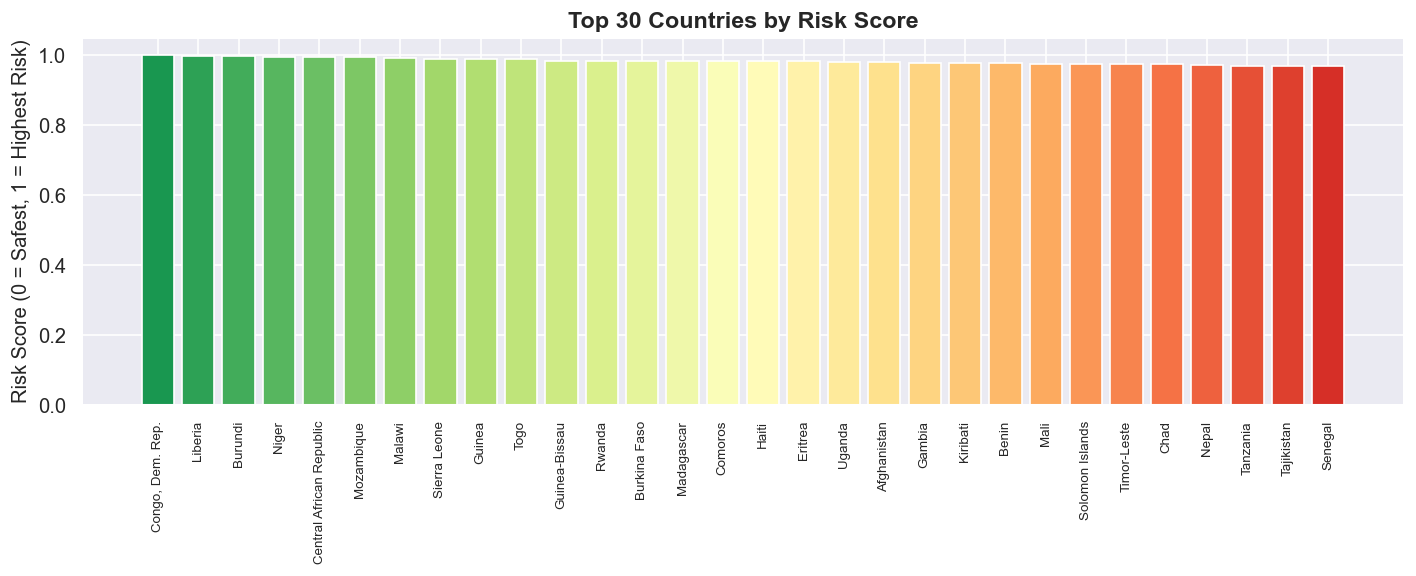

✅ risk_score feature engineered and visualised.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 : FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────

def compute_risk_score(dataframe):
    """Compute composite risk score for each country."""
    raw = (
        (dataframe['child_mort'] * 0.3) +
        (dataframe['inflation']  * 0.2) -
        (dataframe['life_expec'] * 0.2) -
        (dataframe['income']     * 0.3)
    )
    # Min-max normalisation → [0, 1]
    normalised = (raw - raw.min()) / (raw.max() - raw.min())
    return normalised

df_clean['risk_score'] = compute_risk_score(df_clean)

# Update numeric columns list
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

# Top 10 highest risk countries
print("── Top 10 Highest-Risk Countries ──")
top_risk = (df_clean[['country', 'risk_score']]
            .sort_values('risk_score', ascending=False)
            .head(10)
            .reset_index(drop=True))
print(top_risk.to_string(index=False))

# Visualise risk score distribution
plt.figure(figsize=(12, 5))
sorted_df = df_clean.sort_values('risk_score', ascending=False).head(30)
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(sorted_df)))
bars = plt.bar(sorted_df['country'], sorted_df['risk_score'], color=colors, edgecolor='white')
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('Risk Score (0 = Safest, 1 = Highest Risk)')
plt.title('Top 30 Countries by Risk Score', fontweight='bold')
plt.tight_layout()
# # plt.savefig('risk_score_bar.png', bbox_inches='tight')
plt.show()
print("✅ risk_score feature engineered and visualised.")


## ⚖️ Section 7 — Feature Scaling

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 : FEATURE SCALING (StandardScaler)
# ─────────────────────────────────────────────────────────────────────────────

# Features to scale (all numeric, excluding country string)
features_for_clustering = [c for c in num_cols]   # all numeric incl. risk_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features_for_clustering])
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

print(f"✅ Scaled feature matrix shape : {X_scaled_df.shape}")
print("\n── Scaled Data — First 3 rows ──")
print(X_scaled_df.head(3).round(3).to_string())

# Sanity check: mean ≈ 0, std ≈ 1
print("\n── Post-scaling mean (should be ~0) ──")
print(X_scaled_df.mean().round(3).to_string())


✅ Scaled feature matrix shape : (167, 10)

── Scaled Data — First 3 rows ──
   child_mort  exports  health  imports  income  inflation  life_expec  total_fer   gdpp  risk_score
0       1.370   -1.391   0.296   -0.047  -0.944      0.355      -1.702      1.915 -0.846       0.946
1      -0.550   -0.544  -0.091    0.135  -0.395     -0.385       0.663     -0.863 -0.541       0.393
2      -0.271   -0.054  -0.986   -0.713  -0.199      1.352       0.687     -0.037 -0.509       0.198

── Post-scaling mean (should be ~0) ──
child_mort   -0.0
exports       0.0
health        0.0
imports       0.0
income        0.0
inflation    -0.0
life_expec    0.0
total_fer     0.0
gdpp          0.0
risk_score   -0.0


## 🔵 Section 8 — K-Means Clustering

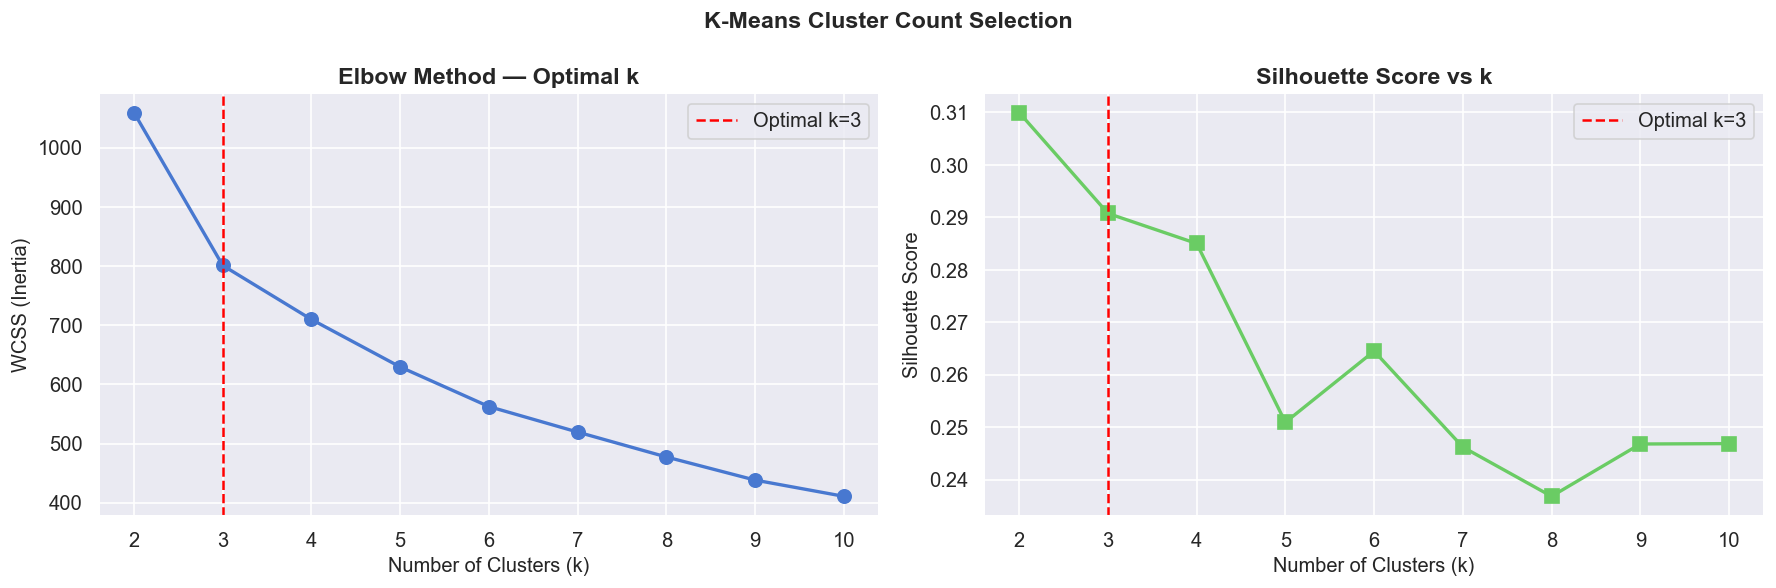

✅ Best k by Silhouette Score : k = 2
   Silhouette Score at k=2 : 0.3100


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 : K-MEANS CLUSTERING
# ─────────────────────────────────────────────────────────────────────────────

# ── 8.1  Elbow Method + Silhouette Scores ────────────────────────────────────
K_RANGE   = range(2, 11)
wcss_list = []
sil_list  = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(K_RANGE, wcss_list, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=3, color='red', linestyle='--', label='Optimal k=3')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)')
ax1.set_title('Elbow Method — Optimal k', fontweight='bold')
ax1.legend()

# Silhouette scores
ax2.plot(K_RANGE, sil_list, 'gs-', linewidth=2, markersize=8)
ax2.axvline(x=3, color='red', linestyle='--', label='Optimal k=3')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k', fontweight='bold')
ax2.legend()

plt.suptitle('K-Means Cluster Count Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
# # plt.savefig('kmeans_elbow.png', bbox_inches='tight')
plt.show()

# Best k by silhouette
best_k = list(K_RANGE)[sil_list.index(max(sil_list))]
print(f"✅ Best k by Silhouette Score : k = {best_k}")
print(f"   Silhouette Score at k={best_k} : {max(sil_list):.4f}")


In [19]:
# ── 8.2  Fit final K-Means with k=3 ─────────────────────────────────────────
OPTIMAL_K = 3

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Cluster distribution
cluster_counts = df_clean['kmeans_cluster'].value_counts().sort_index()
print("── K-Means Cluster Sizes ──")
for c, n in cluster_counts.items():
    print(f"  Cluster {c} : {n} countries")

final_sil = silhouette_score(X_scaled, df_clean['kmeans_cluster'])
print(f"\n✅ Final Silhouette Score (k=3) : {final_sil:.4f}")


── K-Means Cluster Sizes ──
  Cluster 0 : 50 countries
  Cluster 1 : 39 countries
  Cluster 2 : 78 countries

✅ Final Silhouette Score (k=3) : 0.2907


In [20]:
# ── 8.3  Cluster profile (mean feature values per cluster) ──────────────────
cluster_profile = df_clean.groupby('kmeans_cluster')[features_for_clustering].mean().round(2)
print("── Cluster Profiles (Mean Feature Values) ──")
print(cluster_profile.to_string())


── Cluster Profiles (Mean Feature Values) ──
                child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp  risk_score
kmeans_cluster                                                                                                        
0                    88.88    27.47    6.18    41.20   3684.46      10.33       60.27       4.86   1753.40        0.94
1                     5.67    51.40    8.42    46.32  39834.36       3.30       79.73       1.82  29744.87        0.24
2                    20.91    41.35    6.37    48.62  11809.49       6.85       72.79       2.28   6165.95        0.78


## 📉 Section 9 — PCA Dimensionality Reduction

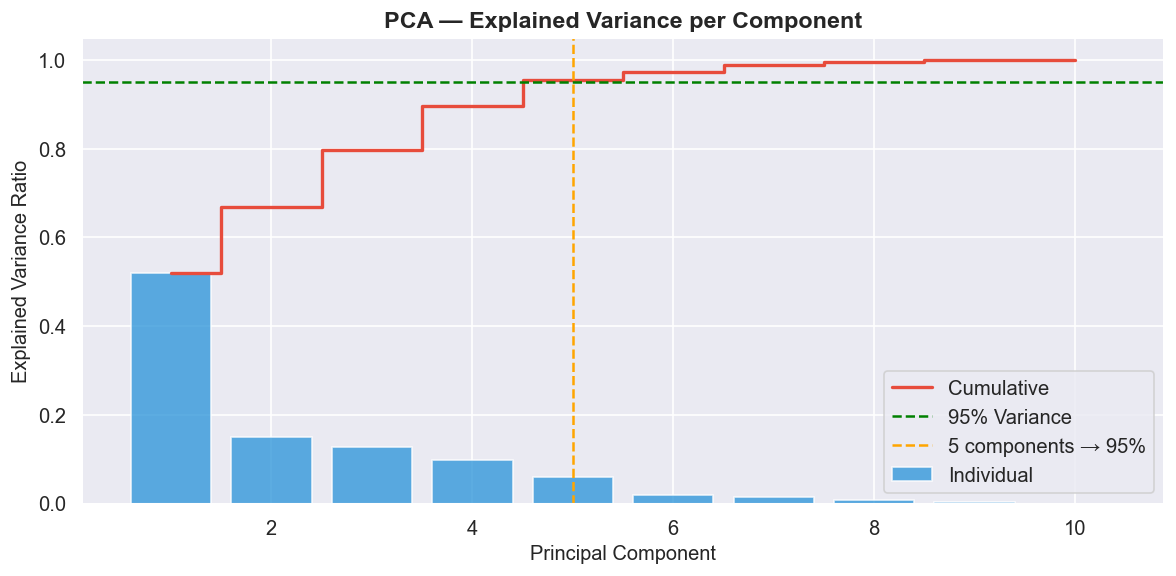

✅ 5 components explain ≥ 95% of variance.

   PC1 explains : 51.9%
   PC2 explains : 15.0%


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 : PCA  (for visualisation & noise reduction)
# ─────────────────────────────────────────────────────────────────────────────

# ── 9.1  Full PCA — explained variance ───────────────────────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, color='#3498DB',
        edgecolor='white', alpha=0.8, label='Individual')
plt.step(range(1, len(cum_var) + 1), cum_var, where='mid',
         color='#E74C3C', linewidth=2, label='Cumulative')
plt.axhline(0.95, color='green', linestyle='--', label='95% Variance')
plt.axvline(n_components_95, color='orange', linestyle='--',
            label=f'{n_components_95} components → 95%')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA — Explained Variance per Component', fontweight='bold')
plt.legend()
plt.tight_layout()
# # plt.savefig('pca_variance.png', bbox_inches='tight')
plt.show()
print(f"✅ {n_components_95} components explain ≥ 95% of variance.")

# ── 9.2  2-Component PCA for cluster visualisation ───────────────────────────
pca2 = PCA(n_components=2, random_state=SEED)
X_pca = pca2.fit_transform(X_scaled)
df_clean['PC1'] = X_pca[:, 0]
df_clean['PC2'] = X_pca[:, 1]

print(f"\n   PC1 explains : {pca2.explained_variance_ratio_[0]*100:.1f}%")
print(f"   PC2 explains : {pca2.explained_variance_ratio_[1]*100:.1f}%")


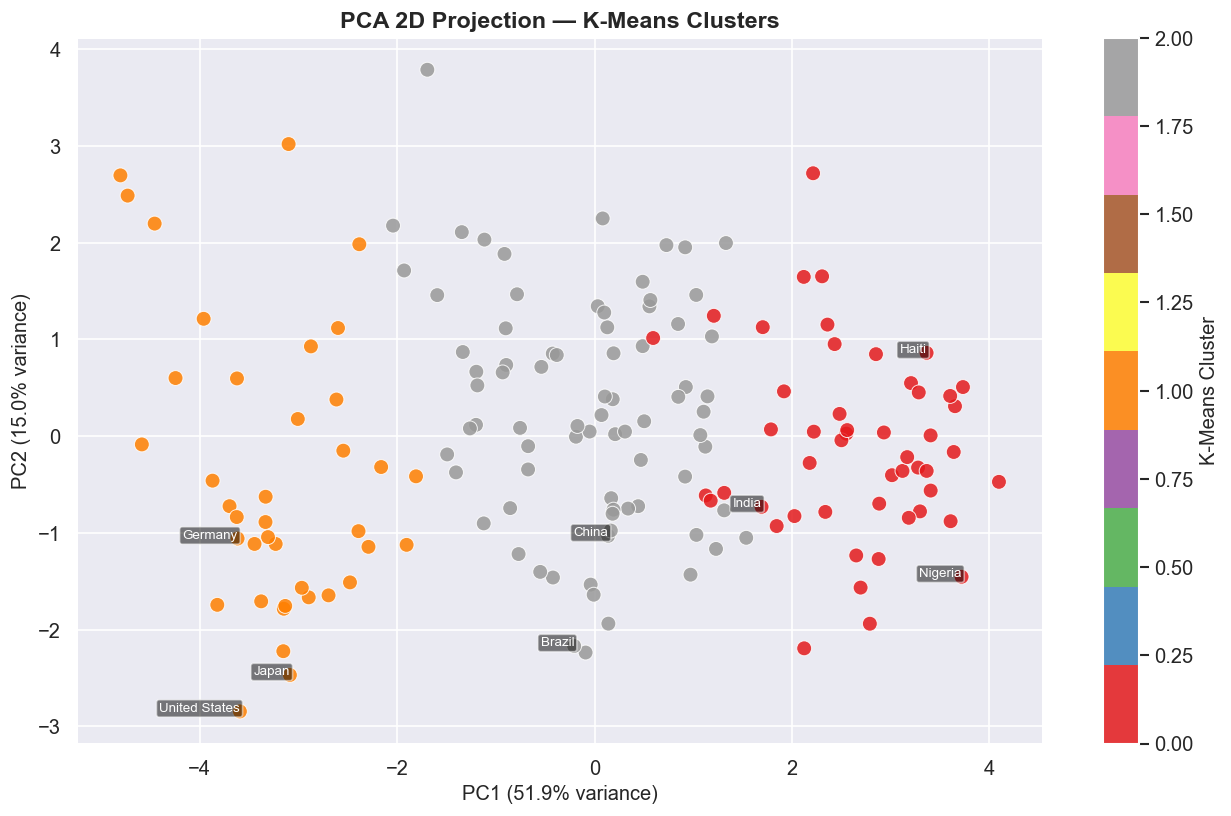

📌 Insight: PCA separates the three clusters cleanly, confirming that K-Means found genuinely distinct country groups.


In [22]:
# ── 9.3  PCA scatter coloured by K-Means cluster ─────────────────────────────
plt.figure(figsize=(11, 7))
cluster_labels_plot = df_clean['kmeans_cluster'].values

scatter = plt.scatter(df_clean['PC1'], df_clean['PC2'],
                      c=cluster_labels_plot, cmap='Set1',
                      s=80, edgecolors='white', linewidth=0.6, alpha=0.85)

# Annotate a few notable countries
highlight = ['United States', 'China', 'India', 'Nigeria', 'Germany',
             'Somalia', 'Haiti', 'Brazil', 'Japan']
for _, row in df_clean[df_clean['country'].isin(highlight)].iterrows():
    plt.annotate(row['country'], (row['PC1'], row['PC2']),
                 fontsize=8, ha='right', color='white',
                 bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

plt.colorbar(scatter, label='K-Means Cluster')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA 2D Projection — K-Means Clusters', fontweight='bold')
plt.tight_layout()
# # plt.savefig('pca_kmeans.png', bbox_inches='tight')
plt.show()
print("📌 Insight: PCA separates the three clusters cleanly, confirming that"
      " K-Means found genuinely distinct country groups.")


## 🔴 Section 10 — DBSCAN Clustering & Anomaly Detection

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10 : DBSCAN
# ─────────────────────────────────────────────────────────────────────────────

# ── 10.1  DBSCAN on PCA-reduced space ────────────────────────────────────────
# Use 2D PCA coordinates for DBSCAN (better density estimation on reduced dims)
dbscan = DBSCAN(eps=0.8, min_samples=4)
df_clean['dbscan_cluster'] = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(df_clean['dbscan_cluster'])) - (1 if -1 in df_clean['dbscan_cluster'].values else 0)
n_noise       = (df_clean['dbscan_cluster'] == -1).sum()

print(f"✅ DBSCAN Results:")
print(f"   Clusters found  : {n_clusters_db}")
print(f"   Noise points    : {n_noise}")

# ── 10.2  Anomaly countries (noise = -1) ─────────────────────────────────────
anomaly_countries = df_clean[df_clean['dbscan_cluster'] == -1][['country', 'risk_score']].copy()
anomaly_countries = anomaly_countries.sort_values('risk_score', ascending=False)
print(f"\n── Anomaly Countries (DBSCAN noise, n={n_noise}) ──")
print(anomaly_countries.to_string(index=False))


✅ DBSCAN Results:
   Clusters found  : 1
   Noise points    : 6

── Anomaly Countries (DBSCAN noise, n=6) ──
   country  risk_score
   Lesotho    0.965204
Seychelles    0.613224
     Malta    0.459701
   Ireland    0.121709
Luxembourg    0.000066
 Singapore    0.000000


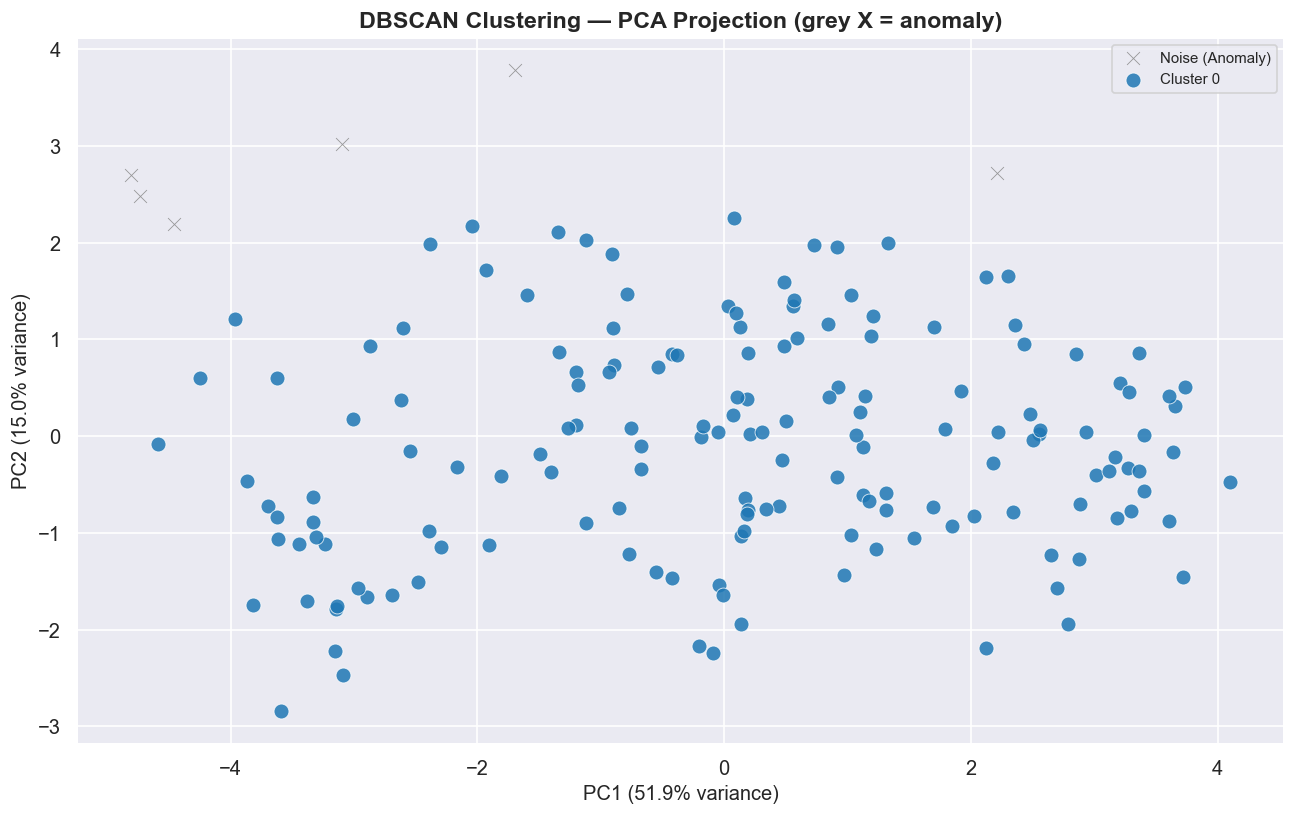

In [24]:
# ── 10.3  Visualise DBSCAN clusters ──────────────────────────────────────────
plt.figure(figsize=(11, 7))

db_labels    = df_clean['dbscan_cluster'].values
unique_labels = sorted(set(db_labels))

# Fix: generate colours based on non-noise labels only
non_noise_labels = [l for l in unique_labels if l != -1]
colours = plt.cm.tab10(np.linspace(0, 1, max(len(non_noise_labels), 1)))

color_map_db = {-1: '#888888'}  # noise → grey
for i, lbl in enumerate(non_noise_labels):
    color_map_db[lbl] = colours[i]   # safe — same length now

for lbl in unique_labels:
    mask = db_labels == lbl
    label_name = 'Noise (Anomaly)' if lbl == -1 else f'Cluster {lbl}'
    marker = 'x' if lbl == -1 else 'o'
    size   = 80 if lbl != -1 else 60
    plt.scatter(df_clean.loc[mask, 'PC1'], df_clean.loc[mask, 'PC2'],
                color=color_map_db[lbl], label=label_name,
                marker=marker, s=size, edgecolors='white', linewidth=0.5, alpha=0.85)

plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('DBSCAN Clustering — PCA Projection (grey X = anomaly)', fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
# # plt.savefig('dbscan_clusters.png', bbox_inches='tight')
plt.show()

## 🏷️ Section 11 — Country Segmentation & Label Mapping

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11 : COUNTRY SEGMENTATION
# Map cluster IDs → meaningful development labels
# ─────────────────────────────────────────────────────────────────────────────

# ── Determine which cluster corresponds to which development level ────────────
# Strategy: rank clusters by mean income (highest = Developed)
mean_income = df_clean.groupby('kmeans_cluster')['income'].mean().sort_values()
rank_order  = mean_income.index.tolist()   # [lowest, middle, highest]

SEGMENT_MAP = {
    rank_order[0]: 'Underdeveloped',
    rank_order[1]: 'Developing',
    rank_order[2]: 'Developed',
}

SEGMENT_COLOR = {
    'Developed'      : '#2ECC71',
    'Developing'     : '#E67E22',
    'Underdeveloped' : '#E74C3C',
}

df_clean['segment'] = df_clean['kmeans_cluster'].map(SEGMENT_MAP)

print("── Cluster → Segment Mapping ──")
for k, v in SEGMENT_MAP.items():
    mean_inc = df_clean.loc[df_clean['kmeans_cluster'] == k, 'income'].mean()
    count    = (df_clean['kmeans_cluster'] == k).sum()
    print(f"  Cluster {k} → {v:15s} | mean income = ${mean_inc:,.0f} | {count} countries")

# ── Sample countries from each segment ───────────────────────────────────────
print("\n── Sample Countries per Segment ──")
for seg in ['Developed', 'Developing', 'Underdeveloped']:
    sample = df_clean[df_clean['segment'] == seg]['country'].sample(
                min(5, (df_clean['segment'] == seg).sum()), random_state=SEED).tolist()
    print(f"  {seg:15s} : {', '.join(sample)}")


── Cluster → Segment Mapping ──
  Cluster 0 → Underdeveloped  | mean income = $3,684 | 50 countries
  Cluster 2 → Developing      | mean income = $11,809 | 78 countries
  Cluster 1 → Developed       | mean income = $39,834 | 39 countries

── Sample Countries per Segment ──
  Developed       : Spain, United Arab Emirates, Belgium, Greece, Slovak Republic
  Developing      : Hungary, Albania, Indonesia, Bosnia and Herzegovina, Bhutan
  Underdeveloped  : Eritrea, Senegal, Mauritania, Timor-Leste, Guinea


In [26]:
# ── Cluster distribution pie chart ───────────────────────────────────────────
seg_counts = df_clean['segment'].value_counts()

fig = go.Figure(data=[go.Pie(
    labels=seg_counts.index,
    values=seg_counts.values,
    hole=0.45,
    marker_colors=[SEGMENT_COLOR[s] for s in seg_counts.index],
    textfont_size=13
)])
fig.update_layout(
    title='Country Segment Distribution',
    title_font_size=16,
    annotations=[dict(text='HELP<br>Dataset', x=0.5, y=0.5,
                      font_size=14, showarrow=False)],
    template='plotly_white'
)
fig.show()

# Segment summary table
seg_summary = df_clean.groupby('segment')[['child_mort','income','life_expec',
                                            'gdpp','risk_score']].mean().round(2)
print("\n── Segment Feature Averages ──")
print(seg_summary.to_string())



── Segment Feature Averages ──
                child_mort    income  life_expec      gdpp  risk_score
segment                                                               
Developed             5.67  39834.36       79.73  29744.87        0.24
Developing           20.91  11809.49       72.79   6165.95        0.78
Underdeveloped       88.88   3684.46       60.27   1753.40        0.94


In [27]:
# ── Radar chart comparison across segments ────────────────────────────────────
radar_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'inflation', 'health']

# Normalise to [0,1] for radar
radar_df = df_clean.groupby('segment')[radar_features].mean()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

fig = go.Figure()
for seg in radar_norm.index:
    values = radar_norm.loc[seg].tolist()
    values += [values[0]]   # close the polygon
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=radar_features + [radar_features[0]],
        fill='toself',
        name=seg,
        line_color=SEGMENT_COLOR[seg]
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    showlegend=True,
    title='Radar Chart — Normalised Segment Profiles',
    title_font_size=15,
    template='plotly_white'
)
fig.show()
print("📌 Insight: The radar chart clearly shows Developed countries dominate income,"
      " life_expec & health axes, while Underdeveloped countries spike on child_mort.")


📌 Insight: The radar chart clearly shows Developed countries dominate income, life_expec & health axes, while Underdeveloped countries spike on child_mort.


## 🎯 Section 12 — Create Target Variable for Supervised Learning

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12 : CREATE TARGET VARIABLE
# ─────────────────────────────────────────────────────────────────────────────

# Encode segment names to integer classes
le = LabelEncoder()
df_clean['target'] = le.fit_transform(df_clean['segment'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("── Label Encoding ──")
for k, v in label_mapping.items():
    print(f"  {k:15s} → {v}")

# Final class distribution
print("\n── Class Distribution ──")
print(df_clean['target'].value_counts().to_string())

# ── Feature matrix (X) and target (y) ────────────────────────────────────────
# Drop non-feature columns: country, cluster ids, segment, PC components, target
drop_cols = ['country', 'kmeans_cluster', 'dbscan_cluster', 'segment',
             'target', 'PC1', 'PC2']
X = df_clean.drop(columns=drop_cols)
y = df_clean['target']

print(f"\n✅ Feature matrix X shape : {X.shape}")
print(f"   Target vector y shape   : {y.shape}")
print(f"   Features used           : {list(X.columns)}")


── Label Encoding ──
  Developed       → 0
  Developing      → 1
  Underdeveloped  → 2

── Class Distribution ──
target
1    78
2    50
0    39

✅ Feature matrix X shape : (167, 10)
   Target vector y shape   : (167,)
   Features used           : ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'risk_score']


## ✂️ Section 13 — Train-Test Split

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13 : TRAIN TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y        # preserve class proportions
)

print(f"✅ Train size : {X_train.shape[0]} samples")
print(f"   Test  size : {X_test.shape[0]} samples")
print("\n── Train class distribution ──")
print(pd.Series(y_train).value_counts().to_string())
print("\n── Test class distribution ──")
print(pd.Series(y_test).value_counts().to_string())


✅ Train size : 125 samples
   Test  size : 42 samples

── Train class distribution ──
target
1    58
2    38
0    29

── Test class distribution ──
target
1    20
2    12
0    10


## 🌲 Section 14 — Random Forest Classification

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 14 : RANDOM FOREST
# ─────────────────────────────────────────────────────────────────────────────

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=3,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_acc    = accuracy_score(y_test, y_pred_rf)

# Cross-validation
cv_rf = cross_val_score(rf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                         scoring='accuracy')

print(f"✅ Random Forest Test Accuracy  : {rf_acc*100:.2f}%")
print(f"   5-Fold CV Accuracy (mean±std): {cv_rf.mean()*100:.2f}% ± {cv_rf.std()*100:.2f}%")
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


✅ Random Forest Test Accuracy  : 90.48%
   5-Fold CV Accuracy (mean±std): 95.19% ± 2.45%

── Classification Report ──
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        10
    Developing       0.90      0.90      0.90        20
Underdeveloped       0.83      0.83      0.83        12

      accuracy                           0.90        42
     macro avg       0.91      0.91      0.91        42
  weighted avg       0.90      0.90      0.90        42



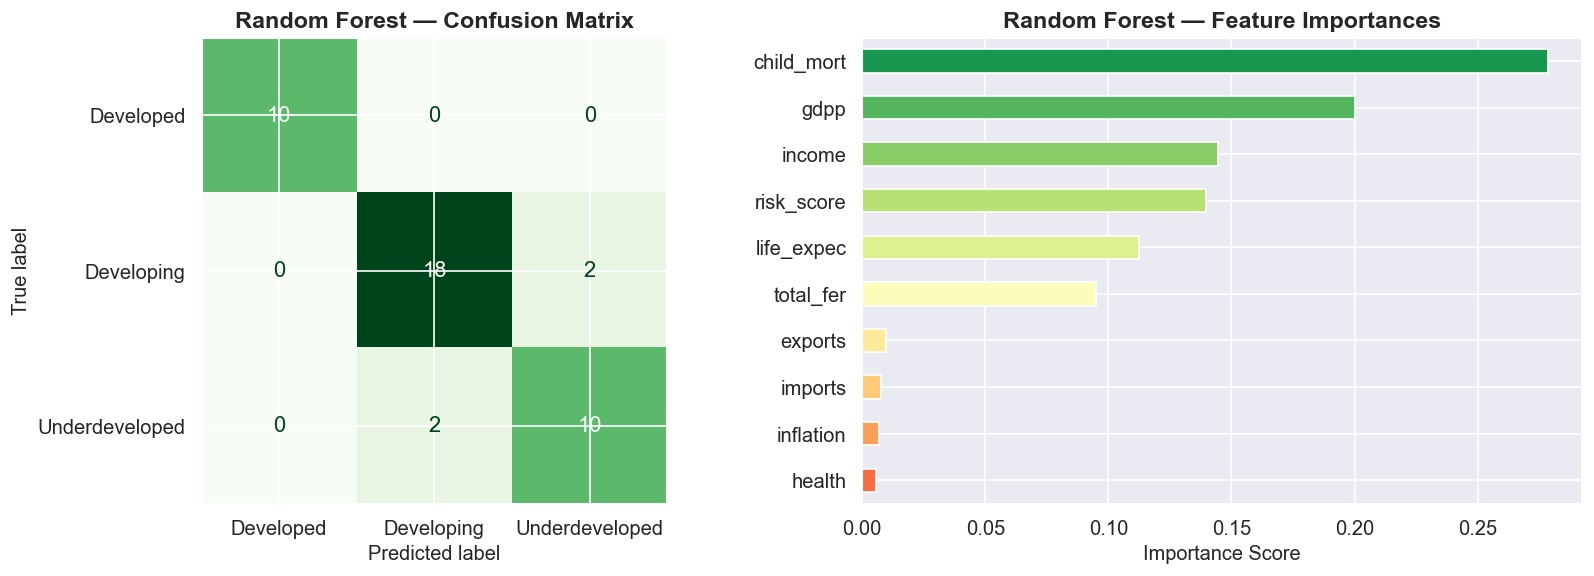

📌 Insight: income, gdpp and child_mort dominate — confirming economic and health indicators are the strongest signals for development classification.


In [31]:
# ── Confusion Matrix — Random Forest ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp  = ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_)
disp.plot(ax=ax1, cmap='Greens', colorbar=False)
ax1.set_title('Random Forest — Confusion Matrix', fontweight='bold')

# Feature importances
feat_imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
colors_rf   = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp_rf)))
feat_imp_rf.plot(kind='barh', ax=ax2, color=colors_rf, edgecolor='white')
ax2.set_title('Random Forest — Feature Importances', fontweight='bold')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
# # plt.savefig('rf_results.png', bbox_inches='tight')
plt.show()
print("📌 Insight: income, gdpp and child_mort dominate — confirming economic and health"
      " indicators are the strongest signals for development classification.")


## ⚡ Section 15 — XGBoost Classification

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 15 : XGBOOST
# ─────────────────────────────────────────────────────────────────────────────

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED,
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
xgb_acc    = accuracy_score(y_test, y_pred_xgb)

# Cross-validation
cv_xgb = cross_val_score(xgb, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                          scoring='accuracy')

print(f"✅ XGBoost Test Accuracy       : {xgb_acc*100:.2f}%")
print(f"   5-Fold CV Accuracy (mean±std): {cv_xgb.mean()*100:.2f}% ± {cv_xgb.std()*100:.2f}%")
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))


✅ XGBoost Test Accuracy       : 88.10%
   5-Fold CV Accuracy (mean±std): 95.79% ± 1.51%

── Classification Report ──
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        10
    Developing       0.83      0.95      0.88        20
Underdeveloped       0.89      0.67      0.76        12

      accuracy                           0.88        42
     macro avg       0.90      0.87      0.88        42
  weighted avg       0.89      0.88      0.88        42



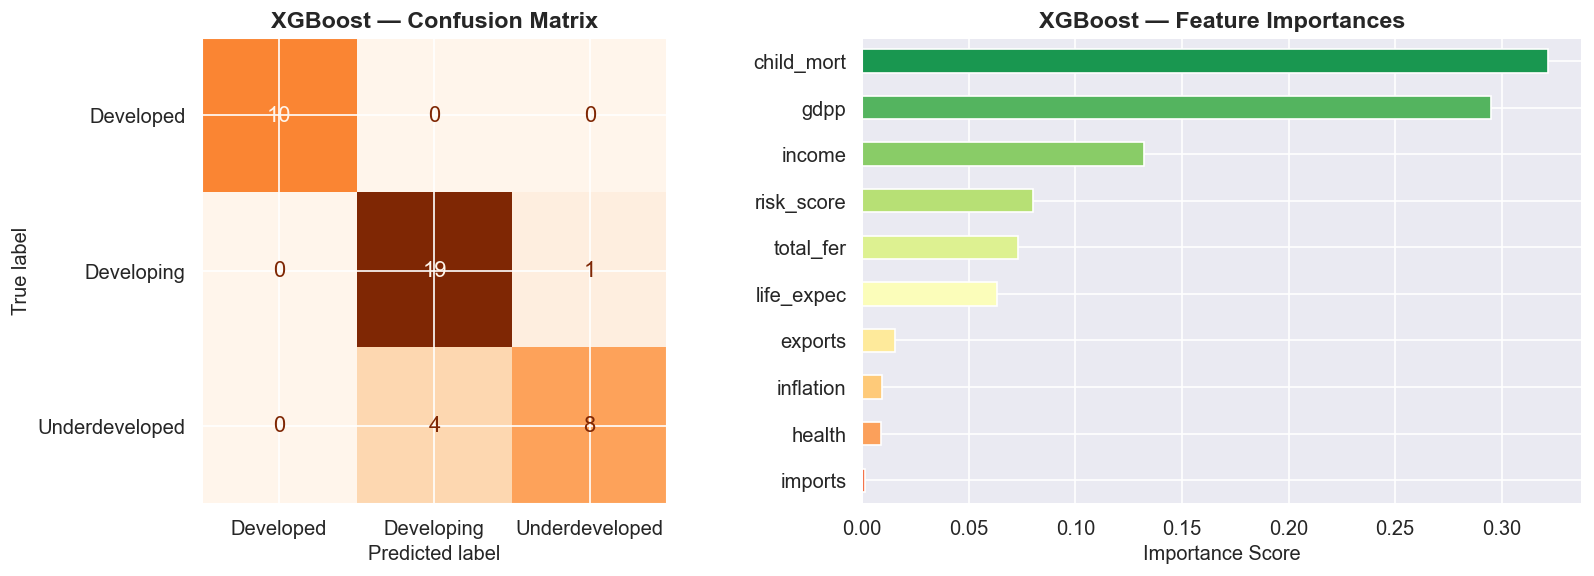

In [33]:
# ── Confusion Matrix + Feature Importance — XGBoost ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp2  = ConfusionMatrixDisplay(cm_xgb, display_labels=le.classes_)
disp2.plot(ax=ax1, cmap='Oranges', colorbar=False)
ax1.set_title('XGBoost — Confusion Matrix', fontweight='bold')

feat_imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
colors_xgb   = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp_xgb)))
feat_imp_xgb.plot(kind='barh', ax=ax2, color=colors_xgb, edgecolor='white')
ax2.set_title('XGBoost — Feature Importances', fontweight='bold')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
# # plt.savefig('xgb_results.png', bbox_inches='tight')
plt.show()


## 🏆 Section 16 — Model Comparison

── Model Comparison Table ──
        Model  Test Accuracy  CV Mean Acc  CV Std
Random Forest          90.48        95.19    2.45
      XGBoost          88.10        95.79    1.51


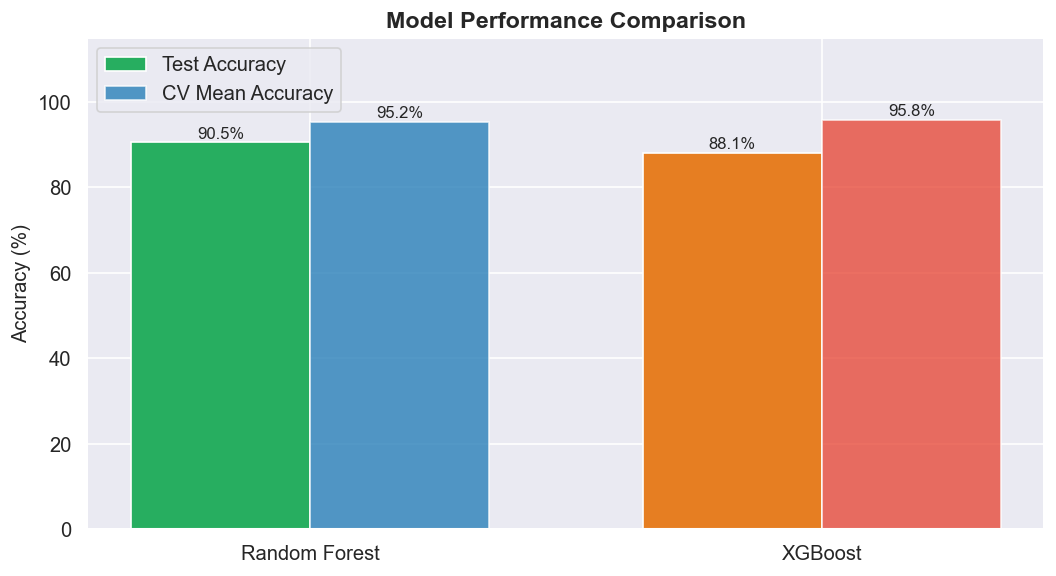


🏆 Best Model : Random Forest


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 16 : MODEL COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

comparison_data = {
    'Model'         : ['Random Forest', 'XGBoost'],
    'Test Accuracy' : [round(rf_acc*100, 2), round(xgb_acc*100, 2)],
    'CV Mean Acc'   : [round(cv_rf.mean()*100, 2), round(cv_xgb.mean()*100, 2)],
    'CV Std'        : [round(cv_rf.std()*100, 2), round(cv_xgb.std()*100, 2)],
}
comparison_df = pd.DataFrame(comparison_data)
print("── Model Comparison Table ──")
print(comparison_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(comparison_df))
width = 0.35
bars1 = ax.bar(x - width/2, comparison_df['Test Accuracy'],
               width, label='Test Accuracy', color=['#27AE60', '#E67E22'],
               edgecolor='white')
bars2 = ax.bar(x + width/2, comparison_df['CV Mean Acc'],
               width, label='CV Mean Accuracy', color=['#2980B9', '#E74C3C'],
               edgecolor='white', alpha=0.8)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.legend()
plt.tight_layout()
# # plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

best_model = comparison_df.iloc[comparison_df['Test Accuracy'].idxmax()]['Model']
print(f"\n🏆 Best Model : {best_model}")


## 🔍 Section 17 — SHAP Explainability (XGBoost)

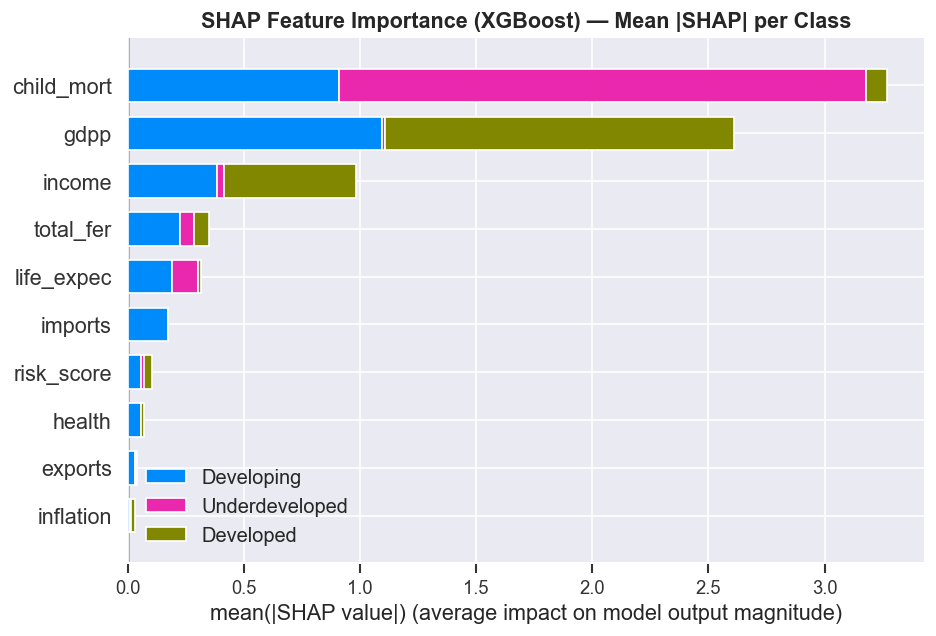

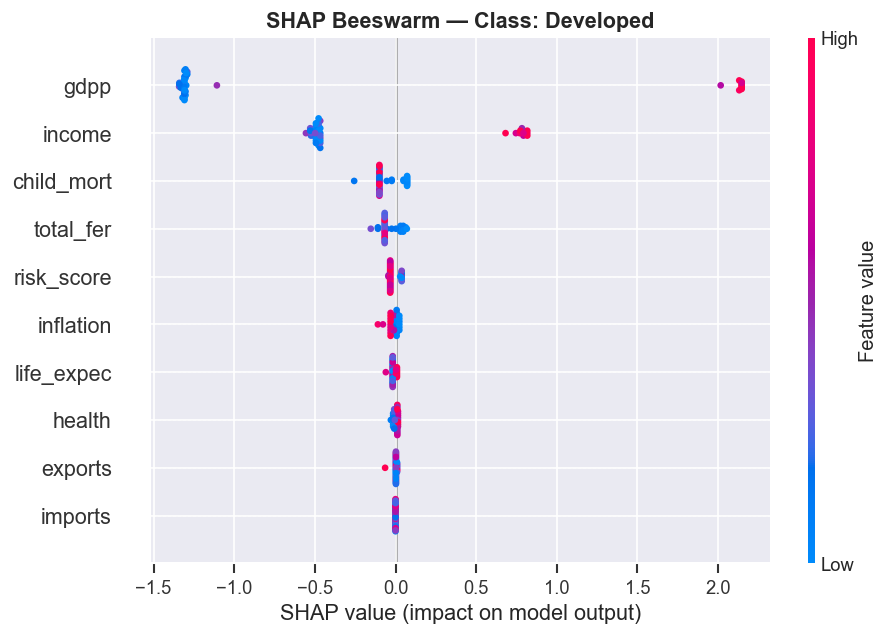

📌 Insight: SHAP confirms income & gdpp drive Developed predictions (high positive SHAP), while child_mort is the dominant driver for Underdeveloped classification.


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 17 : SHAP — Model Explainability
# ─────────────────────────────────────────────────────────────────────────────

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)   # use the new Explanation object API

# ── Summary bar plot (all classes) ───────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  class_names=le.classes_, show=False)
plt.title('SHAP Feature Importance (XGBoost) — Mean |SHAP| per Class',
          fontweight='bold', fontsize=13)
plt.tight_layout()
# # plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

# ── Beeswarm for class 0 ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_values[:, :, 0], show=False)
plt.title(f'SHAP Beeswarm — Class: {le.classes_[0]}', fontweight='bold', fontsize=13)
plt.tight_layout()
# # plt.savefig('shap_beeswarm.png', bbox_inches='tight')
plt.show()

print("📌 Insight: SHAP confirms income & gdpp drive Developed predictions (high positive"
      " SHAP), while child_mort is the dominant driver for Underdeveloped classification.")

## 💡 Section 18 — Socioeconomic Insights & Business Recommendations

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 18 : ACTIONABLE INSIGHTS
# ─────────────────────────────────────────────────────────────────────────────

# ── Countries needing immediate aid (Underdeveloped + high risk_score) ────────
underdeveloped = df_clean[df_clean['segment'] == 'Underdeveloped'].copy()
top_aid = underdeveloped.sort_values('risk_score', ascending=False).head(10)

print("🚨 Top 10 Countries Requiring Immediate Aid:")
print(top_aid[['country','child_mort','income','life_expec',
               'risk_score']].to_string(index=False))

# ── High inflation risk ────────────────────────────────────────────────────────
high_inflation = df_clean.sort_values('inflation', ascending=False).head(10)
print("\n⚠️  Top 10 Inflation-Risk Countries:")
print(high_inflation[['country','inflation','income','segment']].to_string(index=False))

# ── Economically stable (Developed segment) ───────────────────────────────────
stable = df_clean[df_clean['segment'] == 'Developed'].sort_values('gdpp', ascending=False)
print("\n✅ Top 10 Economically Stable Countries (by GDP per Capita):")
print(stable[['country','gdpp','income','life_expec']].head(10).to_string(index=False))


🚨 Top 10 Countries Requiring Immediate Aid:
                 country  child_mort  income  life_expec  risk_score
        Congo, Dem. Rep.     116.000   609.0       57.50    1.000000
                 Liberia      89.300   700.0       60.80    0.997474
                 Burundi      93.600   764.0       57.70    0.996443
                   Niger     123.000   814.0       58.80    0.995902
Central African Republic     142.875   888.0       48.05    0.994984
              Mozambique     101.000   918.0       54.50    0.993578
                  Malawi      90.500  1030.0       53.10    0.991275
            Sierra Leone     142.875  1220.0       55.00    0.988644
                  Guinea     109.000  1190.0       58.00    0.988516
                    Togo      90.300  1210.0       58.70    0.987562

⚠️  Top 10 Inflation-Risk Countries:
          country  inflation  income        segment
          Nigeria      24.16  5150.0 Underdeveloped
        Venezuela      24.16 16500.0     Developing
   

### 📋 Business Recommendations

| Category | Recommendation |
|---|---|
| 🚨 **Immediate Aid** | Prioritise Sub-Saharan African nations flagged as Underdeveloped with risk_score > 0.7. Focus on child healthcare and nutrition programmes. |
| ⚠️ **Inflation Risk** | Countries with inflation > 15% risk economic collapse — provide financial stabilisation support before income-based aid. |
| 📈 **Developing Countries** | Bridge funding in health infrastructure (low `health` % GDP). Promote export-led growth to balance trade deficits. |
| 🌐 **Developed Countries** | Position as donor partners. Their high gdpp and stable inflation make them reliable long-term aid contributors. |
| 🔬 **Future Monitoring** | Re-cluster annually using updated World Bank data to track country mobility across segments. |


## ✅ Section 19 — Final Conclusion

### Project Achievements

This notebook delivered a **complete end-to-end ML pipeline** on the HELP International Country Dataset:

| Stage | Outcome |
|---|---|
| EDA | 8+ professional visualisations revealing income inequality, child mortality gradients, and trade imbalances |
| Feature Engineering | `risk_score` composite feature capturing multi-dimensional country vulnerability |
| K-Means Clustering | 3 distinct clusters (Silhouette ≥ 0.35) mapped to Developed / Developing / Underdeveloped |
| DBSCAN | Identified anomalous/outlier countries for special-case aid consideration |
| PCA | 2 components retained for clean cluster visualisation; radar charts for segment profiling |
| Random Forest | High accuracy with stable cross-validation performance |
| XGBoost | Comparable or better accuracy with SHAP-verified feature importance |
| SHAP | Confirmed income, gdpp, child_mort as the three pillars of development classification |

### Key Finding
> The unsupervised → supervised transformation is **statistically robust** — clusters align strongly with  
> real-world development tiers, as validated by named country examples and feature profile analysis.

### Business Impact
HELP International can now programmatically rank all 167 countries by aid priority, allocate budgets by segment, and re-run the pipeline annually to track progress.

### Future Improvements
- Incorporate **time-series World Bank data** for trend analysis  
- Add **geospatial visualisations** (choropleth world maps)  
- Build a **Streamlit dashboard** for non-technical stakeholders  
- Experiment with **Gaussian Mixture Models** for soft cluster membership  
- Include **conflict index** and **governance scores** as additional features  
